### PTB-XL ECG Deep Learning Training
#### CardioFusion-XAI

This notebook trains the ECG modality of CardioFusion-XAI.

Tasks:
1. Diagnostic superclass prediction
2. Rhythm prediction

The training pipeline is designed for:
- patient-safe evaluation
- PTB-XL official fold splits
- multi-label classification
- class imbalance
- validation-only threshold optimization
- validation-based checkpoint selection
- reproducible experiments
- detailed test evaluation

The test set is kept untouched until final evaluation.

In [100]:
from pathlib import Path
import copy
import json
import math
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    100
)

pd.set_option(
    "display.width",
    160
)

print(
    "PyTorch:",
    torch.__version__
)

PyTorch: 2.14.0+cu130


In [101]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 13.0


In [102]:
SEED = 42

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproducible CUDA behavior.
    # This can reduce performance slightly, but improves
    # reproducibility between runs.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

print("Seed:", SEED)

Seed: 42


In [103]:
PROJECT_ROOT = Path("../../").resolve()

# Must match the preprocessing version you actually created.
PREPROCESSING_VERSION = "100hz_record_zscore"

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ecg"
    / "ptbxl"
    / PREPROCESSING_VERSION
)

MANIFEST_PATH = (
    PROCESSED_DIR
    / "manifests"
    / "ptbxl_manifest.csv"
)

PREPROCESSING_CONFIG_PATH = (
    PROCESSED_DIR
    / "preprocessing_config.json"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "ecg"
    / "ptbxl"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "ecg"
    / PREPROCESSING_VERSION
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed directory:")
print(PROCESSED_DIR)

print("\nManifest:")
print(MANIFEST_PATH)

print("\nManifest exists:")
print(MANIFEST_PATH.exists())

Processed directory:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore

Manifest:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore\manifests\ptbxl_manifest.csv

Manifest exists:
True


In [104]:
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Processed manifest not found:\n{MANIFEST_PATH}\n\n"
        "Check PREPROCESSING_VERSION."
    )

if not PREPROCESSING_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Preprocessing configuration not found:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )

with open(
    PREPROCESSING_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as f:

    preprocessing_config = json.load(f)


print(
    json.dumps(
        preprocessing_config,
        indent=2
    )
)

{
  "dataset": "PTB-XL",
  "version_name": "100hz_record_zscore",
  "random_seed": 42,
  "source_waveform": "filename_lr",
  "sampling": {
    "target_fs_hz": 100,
    "duration_seconds": 10,
    "target_length": 1000
  },
  "signal": {
    "num_leads": 12,
    "lead_names": [
      "I",
      "II",
      "III",
      "AVR",
      "AVL",
      "AVF",
      "V1",
      "V2",
      "V3",
      "V4",
      "V5",
      "V6"
    ]
  },
  "filter": {
    "enabled": true,
    "type": "butterworth_highpass",
    "cutoff_hz": 0.5,
    "order": 3,
    "zero_phase": true
  },
  "resampling": {
    "method": "scipy.signal.resample_poly"
  },
  "length_policy": {
    "mode": "strict",
    "truncate": false,
    "zero_pad": false
  },
  "normalization": {
    "mode": "train_global_zscore",
    "epsilon": 1e-08,
    "statistics_source": "train_only"
  },
  "split": {
    "train_folds": [
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8
    ],
    "validation_folds": [
      9
  

In [105]:
ptbxl = pd.read_csv(
    MANIFEST_PATH
)

print(
    "Manifest shape:",
    ptbxl.shape
)

display(
    ptbxl.head()
)

Manifest shape: (21837, 25)


,ecg_id,patient_id,record_name,processed_path,split,strat_fold,original_fs,original_shape,resampled_shape,final_shape,final_dtype,NORM,MI,STTC,CD,HYP,RHYTHM_SR,RHYTHM_AFIB,RHYTHM_AFLT,RHYTHM_STACH,RHYTHM_SBRAD,RHYTHM_SARRH,RHYTHM_PSVT,RHYTHM_BIGU,RHYTHM_PACE
0,1,15709,records100/00000/00001_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,3,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,13243,records100/00000/00002_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,2,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,20372,records100/00000/00003_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,5,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,17014,records100/00000/00004_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,3,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,17448,records100/00000/00005_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,4,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [106]:
DIAGNOSTIC_LABELS = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP",
]

diagnostic_targets = [
    column
    for column in DIAGNOSTIC_LABELS
    if column in ptbxl.columns
]

rhythm_targets = [
    column
    for column in ptbxl.columns
    if column.startswith("RHYTHM_")
]

if not diagnostic_targets:
    raise ValueError(
        "No diagnostic targets found."
    )

print(
    "Diagnostic targets:"
)

print(
    diagnostic_targets
)

print(
    "\nRhythm targets:"
)

print(
    rhythm_targets
)

Diagnostic targets:
['NORM', 'MI', 'STTC', 'CD', 'HYP']

Rhythm targets:
['RHYTHM_SR', 'RHYTHM_AFIB', 'RHYTHM_AFLT', 'RHYTHM_STACH', 'RHYTHM_SBRAD', 'RHYTHM_SARRH', 'RHYTHM_PSVT', 'RHYTHM_BIGU', 'RHYTHM_PACE']


In [107]:
required_columns = [
    "ecg_id",
    "patient_id",
    "processed_path",
    "split",
]

missing_columns = [
    column
    for column in required_columns
    if column not in ptbxl.columns
]

if missing_columns:
    raise ValueError(
        "Missing manifest columns:\n"
        + "\n".join(missing_columns)
    )

allowed_splits = {
    "train",
    "val",
    "test",
}

if not ptbxl["split"].isin(
    allowed_splits
).all():

    raise ValueError(
        "Manifest contains unexpected split values."
    )

if ptbxl["ecg_id"].duplicated().any():

    raise ValueError(
        "Duplicate ECG IDs found in manifest."
    )

if ptbxl["patient_id"].isna().any():

    raise ValueError(
        "Missing patient IDs found in manifest."
    )

print(
    "Manifest integrity checks passed."
)

Manifest integrity checks passed.


In [108]:
train_df = (
    ptbxl[
        ptbxl["split"] == "train"
    ]
    .copy()
)

val_df = (
    ptbxl[
        ptbxl["split"] == "val"
    ]
    .copy()
)

test_df = (
    ptbxl[
        ptbxl["split"] == "test"
    ]
    .copy()
)

print(
    f"Train      : {len(train_df):,}"
)

print(
    f"Validation : {len(val_df):,}"
)

print(
    f"Test       : {len(test_df):,}"
)

Train      : 17,441
Validation : 2,193
Test       : 2,203


In [109]:
train_patients = set(
    train_df["patient_id"]
)

val_patients = set(
    val_df["patient_id"]
)

test_patients = set(
    test_df["patient_id"]
)

train_val_overlap = (
    train_patients &
    val_patients
)

train_test_overlap = (
    train_patients &
    test_patients
)

val_test_overlap = (
    val_patients &
    test_patients
)

print(
    "Train ∩ Val :",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Val ∩ Test  :",
    len(val_test_overlap)
)

if any([
    train_val_overlap,
    train_test_overlap,
    val_test_overlap,
]):

    raise RuntimeError(
        "Patient leakage detected."
    )

print(
    "\nPatient-level split integrity passed."
)

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Patient-level split integrity passed.


In [110]:
def resolve_processed_path(
    relative_path: str
) -> Path:

    return (
        PROJECT_ROOT /
        Path(relative_path)
    )


sample_path = resolve_processed_path(
    ptbxl.iloc[0]["processed_path"]
)

if not sample_path.exists():
    raise FileNotFoundError(
        f"Processed ECG not found:\n{sample_path}"
    )

sample_signal = np.load(
    sample_path,
    allow_pickle=False
)

if sample_signal.ndim != 2:
    raise ValueError(
        f"Expected [time, leads], "
        f"got {sample_signal.shape}"
    )

SIGNAL_LENGTH = sample_signal.shape[0]
NUM_LEADS = sample_signal.shape[1]

print(
    "Signal length:",
    SIGNAL_LENGTH
)

print(
    "Number of leads:",
    NUM_LEADS
)

print(
    "Signal dtype:",
    sample_signal.dtype
)

del sample_signal

Signal length: 1000
Number of leads: 12
Signal dtype: float32


In [111]:
target_columns = (
    diagnostic_targets +
    rhythm_targets
)

missing_targets = (
    ptbxl[target_columns]
    .isna()
    .sum()
)

display(
    missing_targets
    .rename("missing")
    .to_frame()
)

if missing_targets.sum() > 0:
    raise ValueError(
        "Missing target values detected."
    )

,missing
NORM,0
MI,0
STTC,0
CD,0
HYP,0
RHYTHM_SR,0
RHYTHM_AFIB,0
RHYTHM_AFLT,0
RHYTHM_STACH,0
RHYTHM_SBRAD,0


In [112]:
class PTBXLDataset(Dataset):

    def __init__(
        self,
        dataframe,
        project_root,
        diagnostic_targets,
        rhythm_targets,
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.project_root = Path(
            project_root
        )

        self.diagnostic_targets = list(
            diagnostic_targets
        )

        self.rhythm_targets = list(
            rhythm_targets
        )

    def __len__(self):

        return len(self.df)

    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[index]

        path = (
            self.project_root /
            row["processed_path"]
        )

        signal = np.load(
            path,
            allow_pickle=False
        )

        if signal.shape != (
            SIGNAL_LENGTH,
            NUM_LEADS
        ):

            raise ValueError(
                f"Unexpected ECG shape "
                f"{signal.shape} at {path}. "
                f"Expected "
                f"({SIGNAL_LENGTH}, {NUM_LEADS})."
            )

        if not np.isfinite(
            signal
        ).all():

            raise ValueError(
                f"Non-finite ECG values at {path}."
            )

        # Processed data:
        # [time, leads]
        #
        # PyTorch Conv1D expects:
        # [channels, time]

        signal = signal.T

        diagnostic = np.asarray(
            [
                row[column]
                for column in self.diagnostic_targets
            ],
            dtype=np.float32
        )

        if self.rhythm_targets:

            rhythm = np.asarray(
                [
                    row[column]
                    for column in self.rhythm_targets
                ],
                dtype=np.float32
            )

        else:

            rhythm = np.empty(
                (0,),
                dtype=np.float32
            )

        return (
            torch.from_numpy(
                signal.astype(
                    np.float32,
                    copy=False
                )
            ),
            torch.from_numpy(
                diagnostic
            ),
            torch.from_numpy(
                rhythm
            ),
        )

In [113]:
train_dataset = PTBXLDataset(
    train_df,
    PROJECT_ROOT,
    diagnostic_targets,
    rhythm_targets,
)

val_dataset = PTBXLDataset(
    val_df,
    PROJECT_ROOT,
    diagnostic_targets,
    rhythm_targets,
)

test_dataset = PTBXLDataset(
    test_df,
    PROJECT_ROOT,
    diagnostic_targets,
    rhythm_targets,
)

print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

print(
    "Test dataset:",
    len(test_dataset)
)

Train dataset: 17441
Validation dataset: 2193
Test dataset: 2203


In [114]:
TRAIN_CONFIG = {
    "batch_size": 32,
    "epochs": 40,
    "learning_rate": 1e-4,
    "weight_decay": 5e-3,

    "optimizer": "adamw",

    "scheduler": {
        "name": "reduce_on_plateau",
        "factor": 0.5,
        "patience": 3,
        "min_lr": 1e-7,
    },

    "gradient_clip_norm": 1.0,

    "early_stopping_patience": 7,

    "num_workers": 0,

    "pin_memory": torch.cuda.is_available(),

    "mixed_precision": torch.cuda.is_available(),
}

print(
    json.dumps(
        TRAIN_CONFIG,
        indent=2
    )
)

{
  "batch_size": 32,
  "epochs": 40,
  "learning_rate": 0.0001,
  "weight_decay": 0.005,
  "optimizer": "adamw",
  "scheduler": {
    "name": "reduce_on_plateau",
    "factor": 0.5,
    "patience": 3,
    "min_lr": 1e-07
  },
  "gradient_clip_norm": 1.0,
  "early_stopping_patience": 7,
  "num_workers": 0,
  "pin_memory": true,
  "mixed_precision": true
}


In [115]:
MODEL_CONFIG = {
    "name": "xresnet1d",

    # Your current implementation supports these nominal depths.
    # Start with 34 because that is the model you already tested.
    "depth": 34,

    "dropout": 0.30,
}

print(
    json.dumps(
        MODEL_CONFIG,
        indent=2
    )
)

{
  "name": "xresnet1d",
  "depth": 34,
  "dropout": 0.3
}


In [116]:
import sys

if str(PROJECT_ROOT) not in sys.path:

    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.models.ecg.xresnet1d import (
    XResNet1D
)


def build_model(
    model_config,
    num_leads,
    signal_length,
    num_diagnostic,
    num_rhythm,
):

    model_name = (
        model_config["name"]
        .lower()
    )

    if model_name == "xresnet1d":

        model = XResNet1D(
            input_channels=num_leads,
            num_diagnostic_classes=(
                num_diagnostic
            ),
            num_rhythm_classes=(
                num_rhythm
            ),
            depth=model_config["depth"],
            dropout=model_config["dropout"],
        )

        return model

    raise ValueError(
        f"Unsupported model: {model_name}"
    )

In [117]:
NUM_DIAGNOSTIC = len(
    diagnostic_targets
)

NUM_RHYTHM = len(
    rhythm_targets
)

model = build_model(
    model_config=MODEL_CONFIG,
    num_leads=NUM_LEADS,
    signal_length=SIGNAL_LENGTH,
    num_diagnostic=NUM_DIAGNOSTIC,
    num_rhythm=NUM_RHYTHM,
)

model = model.to(
    DEVICE
)

print(model)

XResNet1D(
  (stem): Sequential(
    (0): Conv1d(12, 64, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): Bottleneck1D(
      (conv1): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv1d(64, 256, kernel_size=(1,), stride=(1,), bias=False)
      (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0)

In [118]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    f"Total parameters     : {total_parameters:,}"
)

print(
    f"Trainable parameters  : "
    f"{trainable_parameters:,}"
)

Total parameters     : 11,185,550
Trainable parameters  : 11,185,550


In [119]:
train_loader_preview = DataLoader(
    train_dataset,
    batch_size=min(
        TRAIN_CONFIG["batch_size"],
        len(train_dataset)
    ),
    shuffle=False,
    num_workers=TRAIN_CONFIG[
        "num_workers"
    ],
)

signals, diagnostic, rhythm = next(
    iter(train_loader_preview)
)

print(
    "Signal:",
    signals.shape
)

print(
    "Diagnostic:",
    diagnostic.shape
)

print(
    "Rhythm:",
    rhythm.shape
)

if signals.shape[1:] != (
    NUM_LEADS,
    SIGNAL_LENGTH
):

    raise ValueError(
        "Unexpected training batch shape."
    )

outputs = model(
    signals.to(DEVICE)
)

print(
    "\nDiagnostic logits:",
    outputs["diagnostic"].shape
)

print(
    "Rhythm logits:",
    outputs["rhythm"].shape
)

Signal: torch.Size([32, 12, 1000])
Diagnostic: torch.Size([32, 5])
Rhythm: torch.Size([32, 9])

Diagnostic logits: torch.Size([32, 5])
Rhythm logits: torch.Size([32, 9])


In [120]:
LOSS_CONFIG = {
    # "none"          -> no class weighting
    # "ratio"         -> negative / positive
    # "sqrt_ratio"    -> sqrt(negative / positive)
    "diagnostic_weighting": "sqrt_ratio",
    "rhythm_weighting": "sqrt_ratio",

    "diagnostic_task_weight": 1.0,
    "rhythm_task_weight": 1.0,
}


def calculate_pos_weights(
    dataframe,
    columns,
    strategy,
):

    if not columns:
        return None

    weights = []

    for column in columns:

        positive = float(
            (dataframe[column] == 1)
            .sum()
        )

        negative = float(
            (dataframe[column] == 0)
            .sum()
        )

        if positive <= 0:
            weight = 1.0

        else:

            ratio = (
                negative /
                positive
            )

            if strategy == "none":

                weight = 1.0

            elif strategy == "ratio":

                weight = ratio

            elif strategy == "sqrt_ratio":

                weight = math.sqrt(
                    ratio
                )

            else:

                raise ValueError(
                    f"Unknown weighting strategy: "
                    f"{strategy}"
                )

        weights.append(
            weight
        )

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE
    )

In [121]:
diagnostic_pos_weight = (
    calculate_pos_weights(
        train_df,
        diagnostic_targets,
        LOSS_CONFIG[
            "diagnostic_weighting"
        ],
    )
)

print(
    "Diagnostic class weights:"
)

print(
    diagnostic_pos_weight
)

if rhythm_targets:

    rhythm_pos_weight = (
        calculate_pos_weights(
            train_df,
            rhythm_targets,
            LOSS_CONFIG[
                "rhythm_weighting"
            ],
        )
    )

    print(
        "\nRhythm class weights:"
    )

    print(
        rhythm_pos_weight
    )

else:

    rhythm_pos_weight = None

Diagnostic class weights:


tensor([1.1370, 1.7245, 1.7775, 1.8597, 2.6876], device='cuda:0')

Rhythm class weights:
tensor([ 0.5469,  3.6609, 17.1642,  5.0384,  5.7676,  5.2174, 30.2811, 16.2252,
         8.5200], device='cuda:0')


In [122]:
weight_table = pd.DataFrame({
    "label": (
        diagnostic_targets +
        rhythm_targets
    ),
    "pos_weight": (
        diagnostic_pos_weight
        .detach()
        .cpu()
        .numpy()
        .tolist()
        +
        (
            rhythm_pos_weight
            .detach()
            .cpu()
            .numpy()
            .tolist()
            if rhythm_pos_weight
            is not None
            else []
        )
    ),
})

display(
    weight_table
)

,label,pos_weight
0,NORM,1.136995
1,MI,1.724470
2,STTC,1.777513
3,CD,1.859659
4,HYP,2.687565
5,RHYTHM_SR,0.546852
6,RHYTHM_AFIB,3.660894
7,RHYTHM_AFLT,17.164211
8,RHYTHM_STACH,5.038430
9,RHYTHM_SBRAD,5.767601


In [123]:
diagnostic_criterion = (
    nn.BCEWithLogitsLoss(
        pos_weight=diagnostic_pos_weight
    )
)

if rhythm_targets:

    rhythm_criterion = (
        nn.BCEWithLogitsLoss(
            pos_weight=rhythm_pos_weight
        )
    )

else:

    rhythm_criterion = None

In [124]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=TRAIN_CONFIG[
        "learning_rate"
    ],
    weight_decay=TRAIN_CONFIG[
        "weight_decay"
    ],
)

print(
    "Optimizer:",
    optimizer.__class__.__name__
)

print(
    "Initial LR:",
    optimizer.param_groups[0]["lr"]
)

Optimizer: AdamW
Initial LR: 0.0001


In [125]:
scheduler_config = (
    TRAIN_CONFIG["scheduler"]
)

if scheduler_config["name"] == (
    "reduce_on_plateau"
):

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=scheduler_config[
                "factor"
            ],
            patience=scheduler_config[
                "patience"
            ],
            min_lr=scheduler_config[
                "min_lr"
            ],
        )
    )

else:

    raise ValueError(
        "Unsupported scheduler."
    )

In [126]:
USE_AMP = (
    TRAIN_CONFIG["mixed_precision"]
    and DEVICE.type == "cuda"
)

if DEVICE.type == "cuda":

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

else:

    scaler = torch.amp.GradScaler(
        "cpu",
        enabled=False
    )

print(
    "Mixed precision:",
    USE_AMP
)

Mixed precision: True


In [127]:
AUGMENTATION_CONFIG = {
    "enabled": True,

    "amplitude": {
        "enabled": True,
        "low": 0.95,
        "high": 1.05,
    },

    "noise": {
        "enabled": True,
        "std": 0.01,
    },

    "time_shift": {
        "enabled": True,
        "fraction": 0.05,
    },

    "lead_dropout": {
        "enabled": True,
        "probability": 0.10,
    },
}

In [128]:
def augment_ecg(
    signals,
    config,
):
    if not config["enabled"]:
        return signals

    out = signals

    batch_size = out.size(0)
    leads = out.size(1)
    length = out.size(2)

    amplitude_config = (
        config["amplitude"]
    )

    if amplitude_config["enabled"]:

        amplitude = (
            torch.empty(
                batch_size,
                1,
                1,
                device=out.device,
                dtype=out.dtype,
            )
            .uniform_(
                amplitude_config["low"],
                amplitude_config["high"],
            )
        )

        out = out * amplitude

    noise_config = (
        config["noise"]
    )

    if noise_config["enabled"]:

        noise = (
            torch.randn_like(out)
            * noise_config["std"]
        )

        out = out + noise

    shift_config = (
        config["time_shift"]
    )

    if shift_config["enabled"]:

        max_shift = int(
            length *
            shift_config["fraction"]
        )

        if max_shift > 0:

            shifts = torch.randint(
                -max_shift,
                max_shift + 1,
                (
                    batch_size,
                ),
                device=out.device,
            )

            shifted = []

            for i in range(
                batch_size
            ):

                shifted.append(
                    torch.roll(
                        out[i],
                        int(
                            shifts[i].item()
                        ),
                        dims=-1,
                    )
                )

            out = torch.stack(
                shifted,
                dim=0
            )

    lead_dropout_config = (
        config["lead_dropout"]
    )

    if lead_dropout_config["enabled"]:

        probability = (
            lead_dropout_config[
                "probability"
            ]
        )

        keep_mask = (
            torch.rand(
                batch_size,
                leads,
                1,
                device=out.device,
            )
            >= probability
        ).to(out.dtype)

        out = out * keep_mask

    return out

In [129]:
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_CONFIG[
        "batch_size"
    ],
    shuffle=True,
    num_workers=TRAIN_CONFIG[
        "num_workers"
    ],
    pin_memory=TRAIN_CONFIG[
        "pin_memory"
    ],
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=TRAIN_CONFIG[
        "batch_size"
    ],
    shuffle=False,
    num_workers=TRAIN_CONFIG[
        "num_workers"
    ],
    pin_memory=TRAIN_CONFIG[
        "pin_memory"
    ],
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TRAIN_CONFIG[
        "batch_size"
    ],
    shuffle=False,
    num_workers=TRAIN_CONFIG[
        "num_workers"
    ],
    pin_memory=TRAIN_CONFIG[
        "pin_memory"
    ],
    drop_last=False,
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 546
Validation batches: 69
Test batches: 69


In [130]:
def compute_loss(
    outputs,
    diagnostic,
    rhythm,
):
    diagnostic_loss = (
        diagnostic_criterion(
            outputs["diagnostic"],
            diagnostic,
        )
    )

    total_loss = (
        LOSS_CONFIG[
            "diagnostic_task_weight"
        ]
        * diagnostic_loss
    )

    rhythm_loss = None

    if rhythm_targets:

        rhythm_loss = (
            rhythm_criterion(
                outputs["rhythm"],
                rhythm,
            )
        )

        total_loss = (
            total_loss
            +
            LOSS_CONFIG[
                "rhythm_task_weight"
            ]
            * rhythm_loss
        )

    return (
        total_loss,
        diagnostic_loss,
        rhythm_loss,
    )

In [131]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for (
        signals,
        diagnostic,
        rhythm,
    ) in loader:

        signals = signals.to(
            DEVICE,
            non_blocking=True,
        )

        diagnostic = diagnostic.to(
            DEVICE,
            non_blocking=True,
        )

        rhythm = rhythm.to(
            DEVICE,
            non_blocking=True,
        )

        signals = augment_ecg(
            signals,
            AUGMENTATION_CONFIG,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):

            outputs = model(
                signals
            )

            (
                loss,
                _,
                _,
            ) = compute_loss(
                outputs,
                diagnostic,
                rhythm,
            )

        scaler.scale(
            loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=TRAIN_CONFIG[
                "gradient_clip_norm"
            ],
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        batch_size = (
            signals.size(0)
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        total_samples += (
            batch_size
        )

    return (
        total_loss /
        total_samples
    )

In [132]:
@torch.no_grad()
def collect_predictions(
    model,
    loader,
):
    model.eval()

    diagnostic_probs = []
    diagnostic_true = []

    rhythm_probs = []
    rhythm_true = []

    total_loss = 0.0
    total_samples = 0

    for (
        signals,
        diagnostic,
        rhythm,
    ) in loader:

        signals = signals.to(
            DEVICE,
            non_blocking=True,
        )

        diagnostic = diagnostic.to(
            DEVICE,
            non_blocking=True,
        )

        rhythm = rhythm.to(
            DEVICE,
            non_blocking=True,
        )

        outputs = model(
            signals
        )

        (
            loss,
            _,
            _,
        ) = compute_loss(
            outputs,
            diagnostic,
            rhythm,
        )

        batch_size = signals.size(0)

        total_loss += (
            loss.item()
            * batch_size
        )

        total_samples += (
            batch_size
        )

        diagnostic_probs.append(
            torch.sigmoid(
                outputs["diagnostic"]
            )
            .cpu()
            .numpy()
        )

        diagnostic_true.append(
            diagnostic
            .cpu()
            .numpy()
        )

        if rhythm_targets:

            rhythm_probs.append(
                torch.sigmoid(
                    outputs["rhythm"]
                )
                .cpu()
                .numpy()
            )

            rhythm_true.append(
                rhythm
                .cpu()
                .numpy()
            )

    result = {
        "loss": (
            total_loss /
            total_samples
        ),
        "diagnostic_probs": np.concatenate(
            diagnostic_probs,
            axis=0,
        ),
        "diagnostic_true": np.concatenate(
            diagnostic_true,
            axis=0,
        ),
    }

    if rhythm_targets:

        result.update({
            "rhythm_probs": np.concatenate(
                rhythm_probs,
                axis=0,
            ),
            "rhythm_true": np.concatenate(
                rhythm_true,
                axis=0,
            ),
        })

    return result

In [133]:
def safe_macro_auroc(
    y_true,
    y_prob,
):
    values = []

    for i in range(
        y_true.shape[1]
    ):

        unique = np.unique(
            y_true[:, i]
        )

        if len(unique) < 2:
            continue

        values.append(
            roc_auc_score(
                y_true[:, i],
                y_prob[:, i],
            )
        )

    if not values:
        return float("nan")

    return float(
        np.mean(values)
    )


def safe_macro_auprc(
    y_true,
    y_prob,
):
    values = []

    for i in range(
        y_true.shape[1]
    ):

        unique = np.unique(
            y_true[:, i]
        )

        if len(unique) < 2:
            continue

        values.append(
            average_precision_score(
                y_true[:, i],
                y_prob[:, i],
            )
        )

    if not values:
        return float("nan")

    return float(
        np.mean(values)
    )

In [134]:
def find_optimal_thresholds(
    y_true,
    y_prob,
    threshold_grid=None,
):
    if threshold_grid is None:

        threshold_grid = np.linspace(
            0.01,
            0.99,
            99,
        )

    thresholds = np.full(
        y_true.shape[1],
        0.5,
        dtype=np.float32,
    )

    threshold_f1 = np.zeros(
        y_true.shape[1],
        dtype=np.float32,
    )

    for i in range(
        y_true.shape[1]
    ):

        best_threshold = 0.5
        best_score = -1.0

        true = y_true[:, i]
        prob = y_prob[:, i]

        if len(
            np.unique(true)
        ) < 2:

            continue

        for threshold in (
            threshold_grid
        ):

            pred = (
                prob >= threshold
            ).astype(int)

            score = f1_score(
                true,
                pred,
                zero_division=0,
            )

            if score > best_score:

                best_score = score
                best_threshold = (
                    threshold
                )

        thresholds[i] = (
            best_threshold
        )

        threshold_f1[i] = (
            best_score
        )

    return (
        thresholds,
        threshold_f1,
    )

In [135]:
def classification_metrics(
    y_true,
    y_prob,
    thresholds,
):
    predictions = (
        y_prob >= thresholds
    ).astype(int)

    return {
        "auroc": safe_macro_auroc(
            y_true,
            y_prob,
        ),

        "auprc": safe_macro_auprc(
            y_true,
            y_prob,
        ),

        "f1": f1_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0,
        ),

        "precision": precision_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0,
        ),

        "recall": recall_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0,
        ),
    }

In [136]:
SELECTION_CONFIG = {
    # Possible choices:
    # "diagnostic_f1"
    # "diagnostic_auroc"
    # "combined_f1"
    # "combined_auroc"
    #
    # Start with combined_f1 because F1 is currently
    # the metric where your model has the largest room
    # for practical improvement.
    "metric": "combined_f1",

    "diagnostic_weight": 0.5,
    "rhythm_weight": 0.5,
}


def calculate_selection_score(
    metrics,
    config,
):
    metric_name = config[
        "metric"
    ]

    if metric_name == (
        "diagnostic_f1"
    ):

        return float(
            metrics[
                "diagnostic_f1"
            ]
        )

    if metric_name == (
        "diagnostic_auroc"
    ):

        return float(
            metrics[
                "diagnostic_auroc"
            ]
        )

    if metric_name == (
        "combined_f1"
    ):

        diagnostic_score = (
            metrics[
                "diagnostic_f1"
            ]
        )

        rhythm_score = (
            metrics.get(
                "rhythm_f1",
                diagnostic_score,
            )
        )

        total_weight = (
            config[
                "diagnostic_weight"
            ]
            +
            config[
                "rhythm_weight"
            ]
        )

        return float(
            (
                config[
                    "diagnostic_weight"
                ]
                * diagnostic_score
                +
                config[
                    "rhythm_weight"
                ]
                * rhythm_score
            )
            / total_weight
        )

    if metric_name == (
        "combined_auroc"
    ):

        diagnostic_score = (
            metrics[
                "diagnostic_auroc"
            ]
        )

        rhythm_score = (
            metrics.get(
                "rhythm_auroc",
                diagnostic_score,
            )
        )

        total_weight = (
            config[
                "diagnostic_weight"
            ]
            +
            config[
                "rhythm_weight"
            ]
        )

        return float(
            (
                config[
                    "diagnostic_weight"
                ]
                * diagnostic_score
                +
                config[
                    "rhythm_weight"
                ]
                * rhythm_score
            )
            / total_weight
        )

    raise ValueError(
        f"Unknown selection metric: "
        f"{metric_name}"
    )

In [137]:
import numpy as np
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def evaluate_validation(
    model,
    loader,
):
    was_training = model.training
    model.eval()

    device = next(model.parameters()).device

    total_loss = 0.0
    total_samples = 0

    diagnostic_targets = []
    diagnostic_probabilities = []

    rhythm_targets_all = []
    rhythm_probabilities = []

    with torch.no_grad():

        for batch in loader:

            if isinstance(batch, dict):

                signals_batch = batch.get(
                    "signals",
                    batch.get("signal"),
                )

                diagnostic_batch = batch[
                    "diagnostic"
                ]

                rhythm_batch = batch.get(
                    "rhythm"
                )

            else:

                signals_batch = batch[0]
                diagnostic_batch = batch[1]
                rhythm_batch = (
                    batch[2]
                    if len(batch) > 2
                    else None
                )

            signals_batch = (
                signals_batch.to(device)
            )

            diagnostic_batch = (
                diagnostic_batch
                .to(device)
                .float()
            )

            if rhythm_batch is not None:
                rhythm_batch = (
                    rhythm_batch
                    .to(device)
                    .float()
                )

            outputs = model(
                signals_batch
            )

            diagnostic_loss = (
                diagnostic_criterion(
                    outputs["diagnostic"],
                    diagnostic_batch,
                )
            )

            loss = diagnostic_loss

            if rhythm_batch is not None:
                loss = loss + rhythm_criterion(
                    outputs["rhythm"],
                    rhythm_batch,
                )

            batch_size = signals_batch.size(0)

            total_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

            diagnostic_targets.append(
                diagnostic_batch.detach().cpu()
            )

            diagnostic_probabilities.append(
                torch.sigmoid(
                    outputs["diagnostic"]
                )
                .detach()
                .cpu()
            )

            if rhythm_batch is not None:
                rhythm_targets_all.append(
                    rhythm_batch.detach().cpu()
                )

                rhythm_probabilities.append(
                    torch.sigmoid(
                        outputs["rhythm"]
                    )
                    .detach()
                    .cpu()
                )

    diagnostic_targets = torch.cat(
        diagnostic_targets
    ).numpy()

    diagnostic_probabilities = torch.cat(
        diagnostic_probabilities
    ).numpy()

    def macro_metric(
        metric,
        targets,
        probabilities,
    ):
        values = []

        for index in range(
            targets.shape[1]
        ):
            target = targets[:, index]
            probability = probabilities[
                :, index
            ]

            if metric == "auroc":
                if len(np.unique(target)) < 2:
                    continue

                values.append(
                    roc_auc_score(
                        target,
                        probability,
                    )
                )

            elif metric == "auprc":
                values.append(
                    average_precision_score(
                        target,
                        probability,
                    )
                )

            else:
                prediction = (
                    probability >= 0.5
                ).astype(int)

                if metric == "f1":
                    values.append(
                        f1_score(
                            target,
                            prediction,
                            zero_division=0,
                        )
                    )

                elif metric == "precision":
                    values.append(
                        precision_score(
                            target,
                            prediction,
                            zero_division=0,
                        )
                    )

                elif metric == "recall":
                    values.append(
                        recall_score(
                            target,
                            prediction,
                            zero_division=0,
                        )
                    )

        return (
            float(np.mean(values))
            if values
            else 0.0
        )

    metrics = {
        "loss": (
            total_loss / total_samples
            if total_samples
            else 0.0
        ),
        "diagnostic_auroc": macro_metric(
            "auroc",
            diagnostic_targets,
            diagnostic_probabilities,
        ),
        "diagnostic_auprc": macro_metric(
            "auprc",
            diagnostic_targets,
            diagnostic_probabilities,
        ),
        "diagnostic_f1": macro_metric(
            "f1",
            diagnostic_targets,
            diagnostic_probabilities,
        ),
        "diagnostic_precision": macro_metric(
            "precision",
            diagnostic_targets,
            diagnostic_probabilities,
        ),
        "diagnostic_recall": macro_metric(
            "recall",
            diagnostic_targets,
            diagnostic_probabilities,
        ),
    }

    if rhythm_targets_all:

        rhythm_targets_array = torch.cat(
            rhythm_targets_all
        ).numpy()

        rhythm_probabilities_array = torch.cat(
            rhythm_probabilities
        ).numpy()

        metrics.update({
            "rhythm_auroc": macro_metric(
                "auroc",
                rhythm_targets_array,
                rhythm_probabilities_array,
            ),
            "rhythm_auprc": macro_metric(
                "auprc",
                rhythm_targets_array,
                rhythm_probabilities_array,
            ),
            "rhythm_f1": macro_metric(
                "f1",
                rhythm_targets_array,
                rhythm_probabilities_array,
            ),
            "rhythm_precision": macro_metric(
                "precision",
                rhythm_targets_array,
                rhythm_probabilities_array,
            ),
            "rhythm_recall": macro_metric(
                "recall",
                rhythm_targets_array,
                rhythm_probabilities_array,
            ),
        })

    if was_training:
        model.train()

    return metrics


PATIENCE = (
    TRAIN_CONFIG[
        "early_stopping_patience"
    ]
)

best_selection_score = -float(
    "inf"
)

best_epoch = None
best_state = None
best_validation_metrics = None

history = []
patience_counter = 0

training_start = time.time()

print("=" * 80)
print("STARTING PTB-XL ECG TRAINING")
print("=" * 80)

print(
    "Model:",
    MODEL_CONFIG
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

for epoch in range(
    1,
    TRAIN_CONFIG["epochs"] + 1,
):

    epoch_start = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
    )

    validation = (
        evaluate_validation(
            model,
            val_loader,
        )
    )

    selection_score = (
        calculate_selection_score(
            validation,
            SELECTION_CONFIG,
        )
    )

    scheduler.step(
        selection_score
    )

    epoch_time = (
        time.time()
        - epoch_start
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": validation[
            "loss"
        ],
        "diagnostic_auroc":
            validation[
                "diagnostic_auroc"
            ],
        "diagnostic_auprc":
            validation[
                "diagnostic_auprc"
            ],
        "diagnostic_f1":
            validation[
                "diagnostic_f1"
            ],
        "diagnostic_precision":
            validation[
                "diagnostic_precision"
            ],
        "diagnostic_recall":
            validation[
                "diagnostic_recall"
            ],
        "selection_score":
            selection_score,
        "learning_rate":
            current_lr,
        "epoch_time_seconds":
            epoch_time,
    }

    if rhythm_targets:

        row.update({
            "rhythm_auroc":
                validation[
                    "rhythm_auroc"
                ],

            "rhythm_auprc":
                validation[
                    "rhythm_auprc"
                ],

            "rhythm_f1":
                validation[
                    "rhythm_f1"
                ],

            "rhythm_precision":
                validation[
                    "rhythm_precision"
                ],

            "rhythm_recall":
                validation[
                    "rhythm_recall"
                ],
        })

    history.append(
        row
    )

    print(
        f"\nEpoch {epoch}"
    )

    print(
        f"Train loss       : "
        f"{train_loss:.4f}"
    )

    print(
        f"Val loss         : "
        f"{validation['loss']:.4f}"
    )

    print(
        f"Diagnostic AUROC : "
        f"{validation['diagnostic_auroc']:.4f}"
    )

    print(
        f"Diagnostic AUPRC  : "
        f"{validation['diagnostic_auprc']:.4f}"
    )

    print(
        f"Diagnostic F1     : "
        f"{validation['diagnostic_f1']:.4f}"
    )

    if rhythm_targets:

        print(
            f"Rhythm AUROC     : "
            f"{validation['rhythm_auroc']:.4f}"
        )

        print(
            f"Rhythm AUPRC     : "
            f"{validation['rhythm_auprc']:.4f}"
        )

        print(
            f"Rhythm F1        : "
            f"{validation['rhythm_f1']:.4f}"
        )

    print(
        f"Selection score   : "
        f"{selection_score:.4f}"
    )

    print(
        f"Learning rate     : "
        f"{current_lr:.8f}"
    )

    if selection_score > (
        best_selection_score
    ):

        best_selection_score = (
            selection_score
        )

        best_epoch = epoch

        best_state = (
            copy.deepcopy(
                model.state_dict()
            )
        )

        best_validation_metrics = (
            validation
        )

        patience_counter = 0

        print(
            "✓ New best checkpoint."
        )

    else:

        patience_counter += 1

        print(
            f"No improvement: "
            f"{patience_counter}/{PATIENCE}"
        )

        if patience_counter >= (
            PATIENCE
        ):

            print(
                "\nEarly stopping."
            )

            break

print()
print("=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation selection score:",
    best_selection_score
)

print(
    "Total training time:",
    round(
        (time.time() - training_start)
        / 60,
        2
    ),
    "minutes"
)

STARTING PTB-XL ECG TRAINING
Model: {'name': 'xresnet1d', 'depth': 34, 'dropout': 0.3}
Train: 17441
Validation: 2193
Test: 2203



Epoch 1
Train loss       : 0.7986
Val loss         : 0.6538
Diagnostic AUROC : 0.8958
Diagnostic AUPRC  : 0.7527
Diagnostic F1     : 0.6888
Rhythm AUROC     : 0.9210
Rhythm AUPRC     : 0.5502
Rhythm F1        : 0.4579
Selection score   : 0.5733
Learning rate     : 0.00010000
✓ New best checkpoint.

Epoch 2
Train loss       : 0.6433
Val loss         : 0.6266
Diagnostic AUROC : 0.9016
Diagnostic AUPRC  : 0.7557
Diagnostic F1     : 0.6767
Rhythm AUROC     : 0.9427
Rhythm AUPRC     : 0.5791
Rhythm F1        : 0.4522
Selection score   : 0.5644
Learning rate     : 0.00010000
No improvement: 1/7

Epoch 3
Train loss       : 0.5915
Val loss         : 0.6213
Diagnostic AUROC : 0.9062
Diagnostic AUPRC  : 0.7714
Diagnostic F1     : 0.6904
Rhythm AUROC     : 0.9554
Rhythm AUPRC     : 0.6096
Rhythm F1        : 0.5177
Selection score   : 0.6041
Learning rate     : 0.00010000
✓ New best checkpoint.

Epoch 4
Train loss       : 0.5592
Val loss         : 0.5876
Diagnostic AUROC : 0.9097
Diagnostic AUPRC

In [138]:
if not history:
    raise RuntimeError(
        "Training history is empty."
    )

history_df = pd.DataFrame(
    history
)

display(
    history_df
)

,epoch,train_loss,val_loss,diagnostic_auroc,diagnostic_auprc,diagnostic_f1,diagnostic_precision,diagnostic_recall,selection_score,learning_rate,epoch_time_seconds,rhythm_auroc,rhythm_auprc,rhythm_f1,rhythm_precision,rhythm_recall
0,1,0.798621,0.653815,0.895783,0.752688,0.688754,0.708425,0.683381,0.573306,0.00010,60.253248,0.920997,0.550177,0.457859,0.465129,0.571488
1,2,0.643319,0.626637,0.901629,0.755735,0.676663,0.679153,0.683450,0.564426,0.00010,69.415010,0.942698,0.579126,0.452189,0.372634,0.715219
2,3,0.591454,0.621267,0.906226,0.771378,0.690440,0.729973,0.677440,0.604058,0.00010,71.575242,0.955378,0.609618,0.517677,0.455290,0.703550
3,4,0.559168,0.587587,0.909680,0.777683,0.698681,0.699382,0.703822,0.629934,0.00010,54.510013,0.955247,0.639574,0.561186,0.478865,0.733034
4,5,0.541142,0.567771,0.917474,0.791456,0.714651,0.704995,0.738242,0.635176,0.00010,50.915500,0.959266,0.644682,0.555700,0.479250,0.756031
5,6,0.522831,0.543078,0.917369,0.796861,0.720221,0.690527,0.766665,0.641765,0.00010,66.185606,0.967457,0.661796,0.563309,0.497101,0.779051
6,7,0.506554,0.554322,0.920407,0.804188,0.724877,0.731379,0.727932,0.650655,0.00010,48.514296,0.969950,0.651862,0.576434,0.523212,0.730711
7,8,0.497361,0.529773,0.920637,0.798691,0.730453,0.715898,0.749831,0.648682,0.00010,50.418483,0.964729,0.670998,0.566912,0.479646,0.787895
8,9,0.487197,0.546224,0.923199,0.803466,0.724178,0.716642,0.737696,0.674935,0.00010,51.776706,0.971010,0.654191,0.625692,0.579911,0.735222
9,10,0.475891,0.574035,0.918431,0.790912,0.712184,0.717482,0.718743,0.651566,0.00010,48.018599,0.969124,0.632293,0.590948,0.543526,0.684803


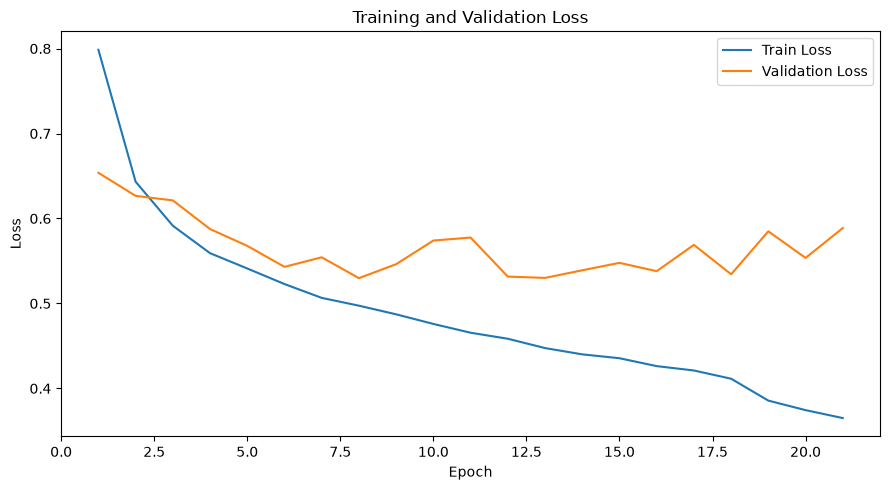

In [139]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.tight_layout()
plt.show()

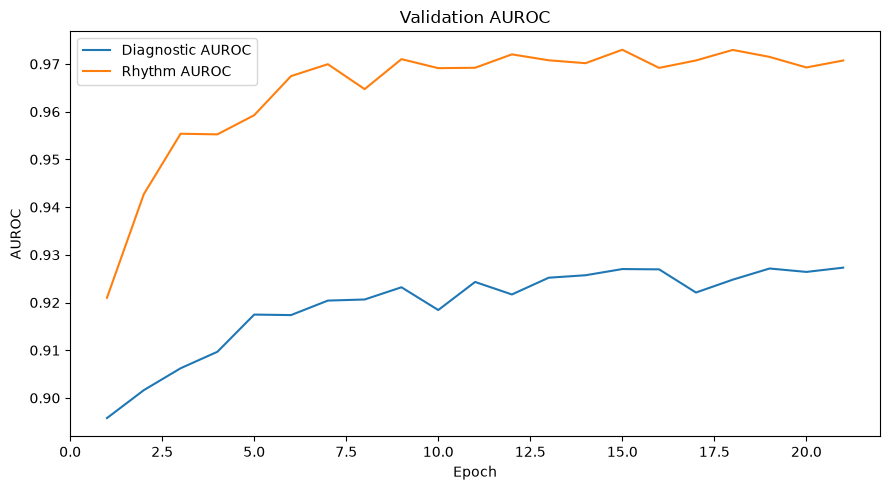

In [140]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["diagnostic_auroc"],
    label="Diagnostic AUROC"
)

if rhythm_targets:

    plt.plot(
        history_df["epoch"],
        history_df["rhythm_auroc"],
        label="Rhythm AUROC"
    )

plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("Validation AUROC")

plt.legend()

plt.tight_layout()
plt.show()

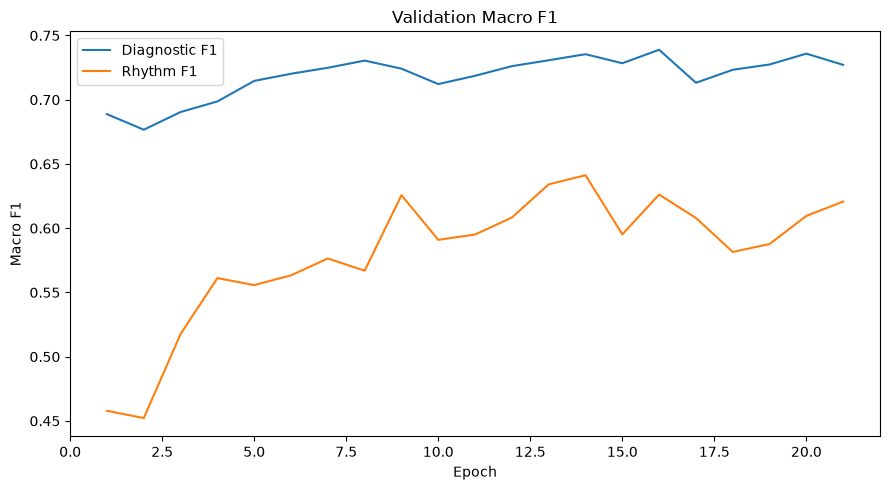

In [141]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["diagnostic_f1"],
    label="Diagnostic F1"
)

if rhythm_targets:

    plt.plot(
        history_df["epoch"],
        history_df["rhythm_f1"],
        label="Rhythm F1"
    )

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1")

plt.legend()

plt.tight_layout()
plt.show()

In [142]:
if best_state is None:

    raise RuntimeError(
        "No best checkpoint was found."
    )

model.load_state_dict(
    best_state,
    strict=True,
)

print(
    "Restored best model."
)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation selection score:",
    best_selection_score
)

Restored best model.
Best epoch: 14
Best validation selection score: 0.688336247750805


In [143]:
best_val_outputs = (
    collect_predictions(
        model,
        val_loader,
    )
)

diagnostic_thresholds, diagnostic_threshold_f1 = (
    find_optimal_thresholds(
        best_val_outputs[
            "diagnostic_true"
        ],
        best_val_outputs[
            "diagnostic_probs"
        ],
    )
)

print(
    "Diagnostic thresholds:"
)

display(
    pd.DataFrame({
        "label": diagnostic_targets,
        "threshold": diagnostic_thresholds,
        "validation_f1": diagnostic_threshold_f1,
    })
)

if rhythm_targets:

    rhythm_thresholds, rhythm_threshold_f1 = (
        find_optimal_thresholds(
            best_val_outputs[
                "rhythm_true"
            ],
            best_val_outputs[
                "rhythm_probs"
            ],
        )
    )

    print(
        "\nRhythm thresholds:"
    )

    display(
        pd.DataFrame({
            "label": rhythm_targets,
            "threshold": rhythm_thresholds,
            "validation_f1": rhythm_threshold_f1,
        })
    )
else:

    rhythm_thresholds = np.empty(
        (0,),
        dtype=np.float32
    )

Diagnostic thresholds:


,label,threshold,validation_f1
0,NORM,0.58,0.864810
1,MI,0.23,0.736667
2,STTC,0.33,0.748166
3,CD,0.63,0.754864
4,HYP,0.42,0.616145



Rhythm thresholds:


,label,threshold,validation_f1
0,RHYTHM_SR,0.36,0.943748
1,RHYTHM_AFIB,0.81,0.869565
2,RHYTHM_AFLT,0.99,0.666667
3,RHYTHM_STACH,0.89,0.858896
4,RHYTHM_SBRAD,0.61,0.704000
5,RHYTHM_SARRH,0.50,0.437086
6,RHYTHM_PSVT,0.15,0.315789
7,RHYTHM_BIGU,0.44,0.526316
8,RHYTHM_PACE,0.27,0.862069


In [144]:
validation_diagnostic_metrics = (
    classification_metrics(
        best_val_outputs[
            "diagnostic_true"
        ],
        best_val_outputs[
            "diagnostic_probs"
        ],
        diagnostic_thresholds,
    )
)

print("=" * 70)
print("BEST MODEL — VALIDATION")
print("=" * 70)

for key, value in (
    validation_diagnostic_metrics.items()
):

    print(
        f"{key:<18}: {value:.6f}"
    )

if rhythm_targets:

    validation_rhythm_metrics = (
        classification_metrics(
            best_val_outputs[
                "rhythm_true"
            ],
            best_val_outputs[
                "rhythm_probs"
            ],
            rhythm_thresholds,
        )
    )

    print()

    for key, value in (
        validation_rhythm_metrics.items()
    ):

        print(
            f"Rhythm {key:<11}: {value:.6f}"
        )

BEST MODEL — VALIDATION
auroc             : 0.925717
auprc             : 0.804964
f1                : 0.744130
precision         : 0.692452
recall            : 0.807029

Rhythm auroc      : 0.970163
Rhythm auprc      : 0.678543
Rhythm f1         : 0.687126
Rhythm precision  : 0.667122
Rhythm recall     : 0.773092


In [145]:
def per_label_report(
    y_true,
    y_prob,
    thresholds,
    labels,
):

    rows = []

    for i, label in enumerate(
        labels
    ):

        true = y_true[:, i]
        prob = y_prob[:, i]

        pred = (
            prob >= thresholds[i]
        ).astype(int)

        if len(
            np.unique(true)
        ) < 2:

            auroc = np.nan
            auprc = np.nan

        else:

            auroc = roc_auc_score(
                true,
                prob,
            )

            auprc = average_precision_score(
                true,
                prob,
            )

        tn, fp, fn, tp = (
            confusion_matrix(
                true,
                pred,
                labels=[0, 1],
            )
            .ravel()
        )

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        rows.append({
            "label": label,
            "AUROC": auroc,
            "AUPRC": auprc,
            "F1": f1_score(
                true,
                pred,
                zero_division=0,
            ),
            "precision": precision_score(
                true,
                pred,
                zero_division=0,
            ),
            "recall": recall_score(
                true,
                pred,
                zero_division=0,
            ),
            "sensitivity": sensitivity,
            "specificity": specificity,
            "support_positive": int(
                true.sum()
            ),
            "threshold": float(
                thresholds[i]
            ),
        })

    return pd.DataFrame(
        rows
    )


validation_diagnostic_report = (
    per_label_report(
        best_val_outputs[
            "diagnostic_true"
        ],
        best_val_outputs[
            "diagnostic_probs"
        ],
        diagnostic_thresholds,
        diagnostic_targets,
    )
)

display(
    validation_diagnostic_report
)

if rhythm_targets:

    validation_rhythm_report = (
        per_label_report(
            best_val_outputs[
                "rhythm_true"
            ],
            best_val_outputs[
                "rhythm_probs"
            ],
            rhythm_thresholds,
            rhythm_targets,
        )
    )

    display(
        validation_rhythm_report
    )

,label,AUROC,AUPRC,F1,precision,recall,sensitivity,specificity,support_positive,threshold
0,NORM,0.945770,0.925802,0.864810,0.838900,0.892372,0.892372,0.867314,957,0.58
1,MI,0.919225,0.814478,0.736667,0.673780,0.812500,0.812500,0.870224,544,0.23
2,STTC,0.929174,0.785405,0.748166,0.662338,0.859551,0.859551,0.858951,534,0.33
3,CD,0.927013,0.844936,0.754864,0.730697,0.780684,0.780684,0.915684,497,0.63
4,HYP,0.907403,0.654198,0.616145,0.556548,0.690037,0.690037,0.922477,271,0.42


,label,AUROC,AUPRC,F1,precision,recall,sensitivity,specificity,support_positive,threshold
0,RHYTHM_SR,0.933646,0.972725,0.943748,0.923560,0.964839,0.964839,0.739806,1678,0.36
1,RHYTHM_AFIB,0.992265,0.909567,0.869565,0.878378,0.860927,0.860927,0.991185,151,0.81
2,RHYTHM_AFLT,0.998170,0.809890,0.666667,0.625000,0.714286,0.714286,0.998628,7,0.99
3,RHYTHM_STACH,0.994250,0.837308,0.858896,0.875000,0.843373,0.843373,0.995261,83,0.89
4,RHYTHM_SBRAD,0.971480,0.691814,0.704000,0.721311,0.687500,0.687500,0.992015,64,0.61
5,RHYTHM_SARRH,0.861157,0.382140,0.437086,0.445946,0.428571,0.428571,0.980624,77,0.50
6,RHYTHM_PSVT,0.995890,0.184722,0.315789,0.187500,1.000000,1.000000,0.994064,3,0.15
7,RHYTHM_BIGU,0.989645,0.428359,0.526316,0.454545,0.625000,0.625000,0.997254,8,0.44
8,RHYTHM_PACE,0.994961,0.890361,0.862069,0.892857,0.833333,0.833333,0.998613,30,0.27


In [146]:
test_outputs = collect_predictions(
    model,
    test_loader,
)

test_diagnostic_metrics = (
    classification_metrics(
        test_outputs[
            "diagnostic_true"
        ],
        test_outputs[
            "diagnostic_probs"
        ],
        diagnostic_thresholds,
    )
)

print("=" * 75)
print("FINAL PTB-XL TEST RESULTS")
print("=" * 75)

print(
    f"Test Loss           : "
    f"{test_outputs['loss']:.6f}"
)

print(
    f"Diagnostic AUROC    : "
    f"{test_diagnostic_metrics['auroc']:.6f}"
)

print(
    f"Diagnostic AUPRC    : "
    f"{test_diagnostic_metrics['auprc']:.6f}"
)

print(
    f"Diagnostic Macro F1 : "
    f"{test_diagnostic_metrics['f1']:.6f}"
)

print(
    f"Diagnostic Precision : "
    f"{test_diagnostic_metrics['precision']:.6f}"
)

print(
    f"Diagnostic Recall    : "
    f"{test_diagnostic_metrics['recall']:.6f}"
)

if rhythm_targets:

    test_rhythm_metrics = (
        classification_metrics(
            test_outputs[
                "rhythm_true"
            ],
            test_outputs[
                "rhythm_probs"
            ],
            rhythm_thresholds,
        )
    )

    print(
        f"\nRhythm AUROC       : "
        f"{test_rhythm_metrics['auroc']:.6f}"
    )

    print(
        f"Rhythm AUPRC       : "
        f"{test_rhythm_metrics['auprc']:.6f}"
    )

    print(
        f"Rhythm Macro F1    : "
        f"{test_rhythm_metrics['f1']:.6f}"
    )

    print(
        f"Rhythm Precision   : "
        f"{test_rhythm_metrics['precision']:.6f}"
    )

    print(
        f"Rhythm Recall      : "
        f"{test_rhythm_metrics['recall']:.6f}"
    )

FINAL PTB-XL TEST RESULTS
Test Loss           : 0.600950
Diagnostic AUROC    : 0.922165
Diagnostic AUPRC    : 0.803364
Diagnostic Macro F1 : 0.735125
Diagnostic Precision : 0.681304
Diagnostic Recall    : 0.801304

Rhythm AUROC       : 0.952629
Rhythm AUPRC       : 0.594313
Rhythm Macro F1    : 0.582287
Rhythm Precision   : 0.642732
Rhythm Recall      : 0.596289


In [147]:
test_diagnostic_report = (
    per_label_report(
        test_outputs[
            "diagnostic_true"
        ],
        test_outputs[
            "diagnostic_probs"
        ],
        diagnostic_thresholds,
        diagnostic_targets,
    )
)

display(
    test_diagnostic_report
)

if rhythm_targets:

    test_rhythm_report = (
        per_label_report(
            test_outputs[
                "rhythm_true"
            ],
            test_outputs[
                "rhythm_probs"
            ],
            rhythm_thresholds,
            rhythm_targets,
        )
    )

    display(
        test_rhythm_report
    )

,label,AUROC,AUPRC,F1,precision,recall,sensitivity,specificity,support_positive,threshold
0,NORM,0.946070,0.922900,0.857848,0.818267,0.901452,0.901452,0.844229,964,0.58
1,MI,0.912790,0.808309,0.717907,0.655224,0.793852,0.793852,0.860000,553,0.23
2,STTC,0.929240,0.800856,0.739635,0.653001,0.852772,0.852772,0.858929,523,0.33
3,CD,0.912350,0.818179,0.739430,0.724470,0.755020,0.755020,0.916129,498,0.63
4,HYP,0.910376,0.666577,0.620805,0.555556,0.703422,0.703422,0.923711,263,0.42


,label,AUROC,AUPRC,F1,precision,recall,sensitivity,specificity,support_positive,threshold
0,RHYTHM_SR,0.895204,0.953173,0.923475,0.892659,0.956496,0.956496,0.632381,1678,0.36
1,RHYTHM_AFIB,0.979586,0.917889,0.838284,0.841060,0.835526,0.835526,0.988298,152,0.81
2,RHYTHM_AFLT,0.970336,0.514759,0.600000,1.000000,0.428571,0.428571,1.000000,7,0.99
3,RHYTHM_STACH,0.993969,0.891047,0.838323,0.823529,0.853659,0.853659,0.992928,82,0.89
4,RHYTHM_SBRAD,0.958151,0.563299,0.538462,0.700000,0.437500,0.437500,0.994390,64,0.61
5,RHYTHM_SARRH,0.882671,0.258766,0.312500,0.301205,0.324675,0.324675,0.972719,77,0.50
6,RHYTHM_PSVT,0.995229,0.138889,0.111111,0.062500,0.500000,0.500000,0.993185,2,0.15
7,RHYTHM_BIGU,0.970444,0.400272,0.333333,0.300000,0.375000,0.375000,0.996811,8,0.44
8,RHYTHM_PACE,0.928068,0.710728,0.745098,0.863636,0.655172,0.655172,0.998620,29,0.27


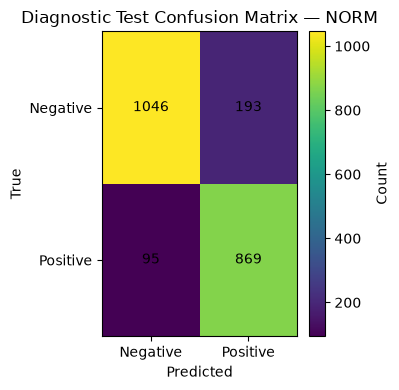

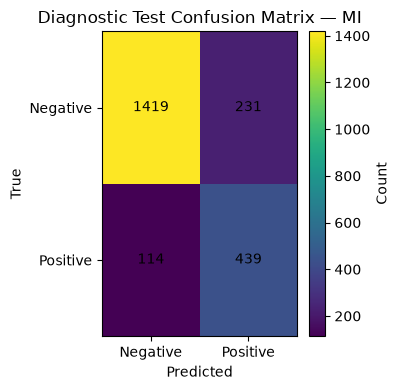

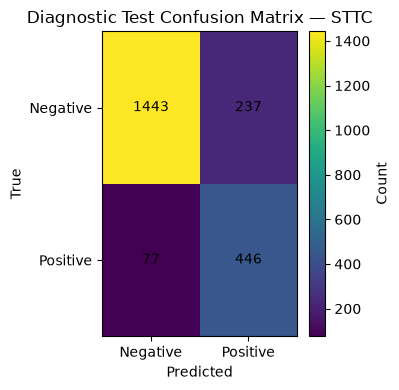

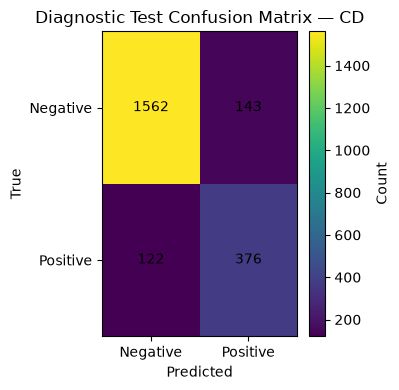

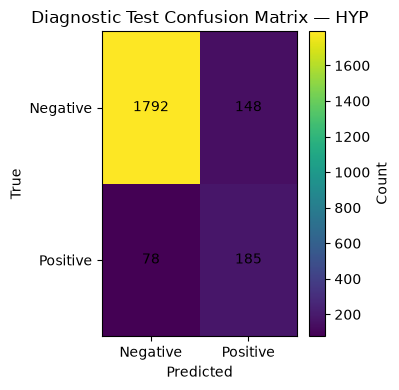

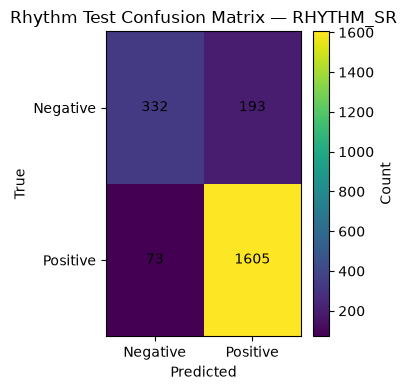

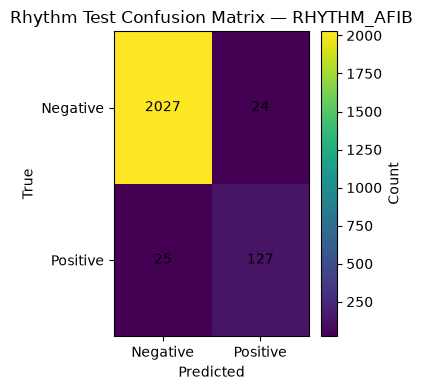

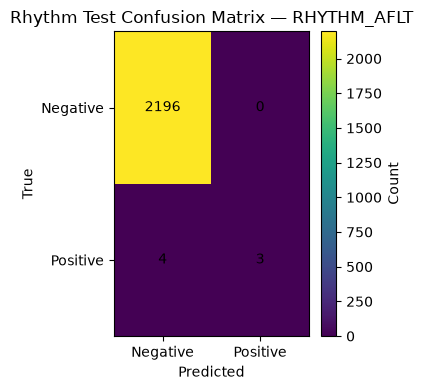

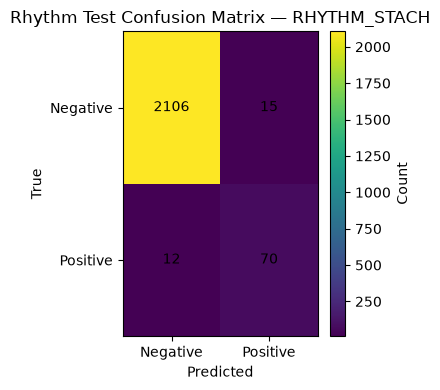

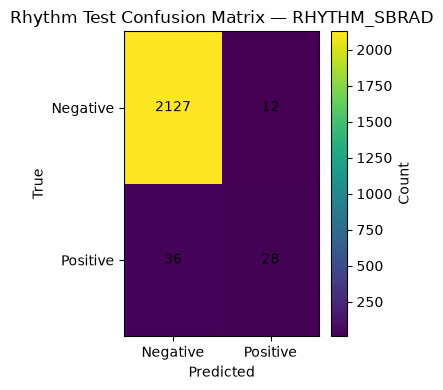

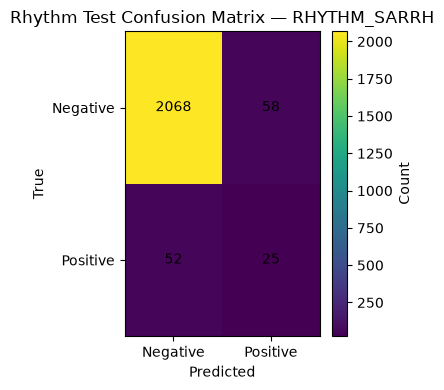

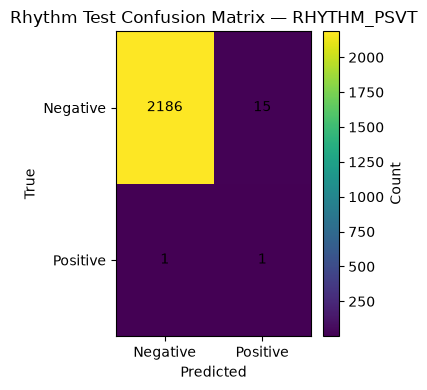

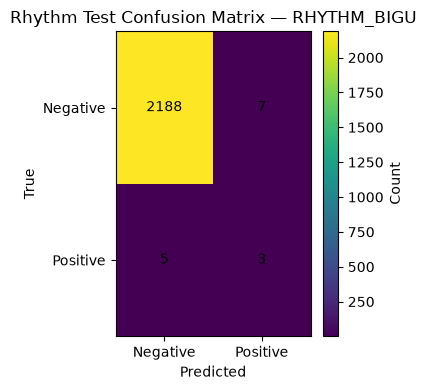

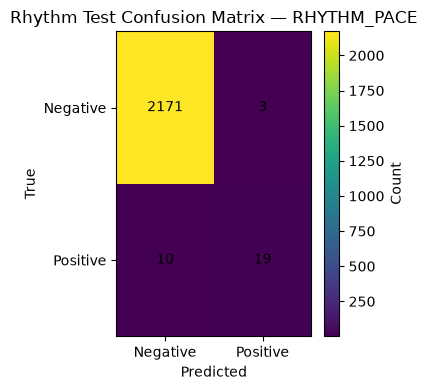

In [148]:
def plot_confusion_matrices(
    y_true,
    y_prob,
    thresholds,
    labels,
    title_prefix,
):

    predictions = (
        y_prob >= thresholds
    ).astype(int)

    for i, label in enumerate(
        labels
    ):

        cm = confusion_matrix(
            y_true[:, i],
            predictions[:, i],
            labels=[0, 1],
        )

        plt.figure(
            figsize=(4, 4)
        )

        plt.imshow(
            cm,
            aspect="auto"
        )

        plt.xticks(
            [0, 1],
            ["Negative", "Positive"]
        )

        plt.yticks(
            [0, 1],
            ["Negative", "Positive"]
        )

        plt.xlabel(
            "Predicted"
        )

        plt.ylabel(
            "True"
        )

        plt.title(
            f"{title_prefix} — {label}"
        )

        plt.colorbar(
            label="Count"
        )

        for row_index in range(2):
            for col_index in range(2):

                plt.text(
                    col_index,
                    row_index,
                    str(
                        cm[
                            row_index,
                            col_index
                        ]
                    ),
                    ha="center",
                    va="center",
                )

        plt.tight_layout()
        plt.show()


plot_confusion_matrices(
    test_outputs[
        "diagnostic_true"
    ],
    test_outputs[
        "diagnostic_probs"
    ],
    diagnostic_thresholds,
    diagnostic_targets,
    "Diagnostic Test Confusion Matrix",
)

if rhythm_targets:

    plot_confusion_matrices(
        test_outputs[
            "rhythm_true"
        ],
        test_outputs[
            "rhythm_probs"
        ],
        rhythm_thresholds,
        rhythm_targets,
        "Rhythm Test Confusion Matrix",
    )

In [149]:
def bootstrap_metric_ci(
    y_true,
    y_prob,
    metric_fn,
    n_bootstrap=1000,
    seed=SEED,
):
    rng = np.random.default_rng(
        seed
    )

    n_samples = len(
        y_true
    )

    values = []

    for _ in range(
        n_bootstrap
    ):

        indices = rng.integers(
            0,
            n_samples,
            size=n_samples,
        )

        true_sample = (
            y_true[indices]
        )

        prob_sample = (
            y_prob[indices]
        )

        if len(
            np.unique(
                true_sample
            )
        ) < 2:

            continue

        values.append(
            metric_fn(
                true_sample,
                prob_sample,
            )
        )

    values = np.asarray(
        values
    )

    estimate = metric_fn(
        y_true,
        y_prob,
    )

    return {
        "estimate": float(
            estimate
        ),
        "lower_95": float(
            np.percentile(
                values,
                2.5
            )
        ),
        "upper_95": float(
            np.percentile(
                values,
                97.5
            )
        ),
    }

In [150]:
diagnostic_bootstrap_rows = []

for i, label in enumerate(
    diagnostic_targets
):

    true = (
        test_outputs[
            "diagnostic_true"
        ][:, i]
    )

    prob = (
        test_outputs[
            "diagnostic_probs"
        ][:, i]
    )

    if len(
        np.unique(true)
    ) < 2:

        continue

    ci = bootstrap_metric_ci(
        true,
        prob,
        roc_auc_score,
    )

    diagnostic_bootstrap_rows.append({
        "label": label,
        "AUROC": ci["estimate"],
        "CI_lower_95": ci["lower_95"],
        "CI_upper_95": ci["upper_95"],
    })

diagnostic_bootstrap_df = pd.DataFrame(
    diagnostic_bootstrap_rows
)

display(
    diagnostic_bootstrap_df
)

,label,AUROC,CI_lower_95,CI_upper_95
0,NORM,0.946070,0.937723,0.954719
1,MI,0.912790,0.900491,0.925249
2,STTC,0.929240,0.917622,0.941018
3,CD,0.912350,0.896770,0.926852
4,HYP,0.910376,0.889950,0.926733


In [151]:
checkpoint_name = (
    f"ptbxl_"
    f"{MODEL_CONFIG['name']}_"
    f"depth{MODEL_CONFIG.get('depth', 'na')}_"
    f"{PREPROCESSING_VERSION}.pt"
)

checkpoint_path = (
    CHECKPOINT_DIR /
    checkpoint_name
)

checkpoint = {
    "model_state_dict":
        model.state_dict(),

    "model_config":
        MODEL_CONFIG,

    "train_config":
        TRAIN_CONFIG,

    "loss_config":
        LOSS_CONFIG,

    "augmentation_config":
        AUGMENTATION_CONFIG,

    "selection_config":
        SELECTION_CONFIG,

    "preprocessing_version":
        PREPROCESSING_VERSION,

    "preprocessing_config":
        preprocessing_config,

    "num_leads":
        NUM_LEADS,

    "signal_length":
        SIGNAL_LENGTH,

    "diagnostic_targets":
        diagnostic_targets,

    "rhythm_targets":
        rhythm_targets,

    "diagnostic_thresholds":
        diagnostic_thresholds,

    "rhythm_thresholds":
        rhythm_thresholds,

    "best_epoch":
        best_epoch,

    "best_validation_selection_score":
        best_selection_score,

    "seed":
        SEED,
}

torch.save(
    checkpoint,
    checkpoint_path
)

print(
    "Checkpoint saved:"
)

print(
    checkpoint_path
)

Checkpoint saved:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\ecg\ptbxl\ptbxl_xresnet1d_depth34_100hz_record_zscore.pt


In [152]:
history_path = (
    RESULTS_DIR /
    "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(
    "Saved:",
    history_path
)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\training_history.csv


In [153]:
final_metrics = {
    "model_config": MODEL_CONFIG,

    "preprocessing_version":
        PREPROCESSING_VERSION,

    "signal_length":
        SIGNAL_LENGTH,

    "num_leads":
        NUM_LEADS,

    "best_epoch":
        best_epoch,

    "best_validation_selection_score":
        best_selection_score,

    "diagnostic_test": {
        key: float(value)
        for key, value in
        test_diagnostic_metrics.items()
    },

    "patient_overlap": {
        "train_val":
            len(train_val_overlap),

        "train_test":
            len(train_test_overlap),

        "val_test":
            len(val_test_overlap),
    },
}

if rhythm_targets:

    final_metrics[
        "rhythm_test"
    ] = {
        key: float(value)
        for key, value in
        test_rhythm_metrics.items()
    }

with open(
    RESULTS_DIR /
    "test_metrics.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        final_metrics,
        f,
        indent=2
    )

print(
    json.dumps(
        final_metrics,
        indent=2
    )
)

{
  "model_config": {
    "name": "xresnet1d",
    "depth": 34,
    "dropout": 0.3
  },
  "preprocessing_version": "100hz_record_zscore",
  "signal_length": 1000,
  "num_leads": 12,
  "best_epoch": 14,
  "best_validation_selection_score": 0.688336247750805,
  "diagnostic_test": {
    "auroc": 0.9221651612482521,
    "auprc": 0.8033641620290973,
    "f1": 0.7351249969506755,
    "precision": 0.6813036910237017,
    "recall": 0.8013037200304897
  },
  "patient_overlap": {
    "train_val": 0,
    "train_test": 0,
    "val_test": 0
  },
  "rhythm_test": {
    "auroc": 0.9526287006288814,
    "auprc": 0.5943133032048125,
    "f1": 0.5822873847462464,
    "precision": 0.6427320785313483,
    "recall": 0.5962888719757555
  }
}


In [154]:
threshold_path = (
    RESULTS_DIR /
    "validation_thresholds.npz"
)

np.savez(
    threshold_path,

    diagnostic=(
        diagnostic_thresholds
    ),

    rhythm=(
        rhythm_thresholds
    ),
)

print(
    "Saved thresholds:"
)

print(
    threshold_path
)

Saved thresholds:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\validation_thresholds.npz


In [155]:
diagnostic_report_path = (
    RESULTS_DIR /
    "test_diagnostic_per_label.csv"
)

test_diagnostic_report.to_csv(
    diagnostic_report_path,
    index=False
)

print(
    "Saved:",
    diagnostic_report_path
)

if rhythm_targets:

    rhythm_report_path = (
        RESULTS_DIR /
        "test_rhythm_per_label.csv"
    )

    test_rhythm_report.to_csv(
        rhythm_report_path,
        index=False
    )

    print(
        "Saved:",
        rhythm_report_path
    )

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\test_diagnostic_per_label.csv
Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\test_rhythm_per_label.csv


In [156]:
experiment_config = {
    "seed": SEED,

    "preprocessing_version":
        PREPROCESSING_VERSION,

    "preprocessing_config":
        preprocessing_config,

    "model_config":
        MODEL_CONFIG,

    "train_config":
        TRAIN_CONFIG,

    "loss_config":
        LOSS_CONFIG,

    "augmentation_config":
        AUGMENTATION_CONFIG,

    "selection_config":
        SELECTION_CONFIG,

    "diagnostic_targets":
        diagnostic_targets,

    "rhythm_targets":
        rhythm_targets,

    "signal_length":
        SIGNAL_LENGTH,

    "num_leads":
        NUM_LEADS,
}

experiment_config_path = (
    RESULTS_DIR /
    "experiment_config.json"
)

with open(
    experiment_config_path,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        experiment_config,
        f,
        indent=2
    )

print(
    "Saved:",
    experiment_config_path
)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\experiment_config.json


In [157]:
print("=" * 80)
print("FINAL TRAINING / EVALUATION INTEGRITY CHECK")
print("=" * 80)

integrity_checks = {
    "Train/Val patient overlap = 0":
        len(train_val_overlap) == 0,

    "Train/Test patient overlap = 0":
        len(train_test_overlap) == 0,

    "Val/Test patient overlap = 0":
        len(val_test_overlap) == 0,

    "Checkpoint exists":
        checkpoint_path.exists(),

    "Threshold file exists":
        threshold_path.exists(),

    "Test metrics contain AUROC":
        "auroc"
        in test_diagnostic_metrics,

    "Test metrics contain AUPRC":
        "auprc"
        in test_diagnostic_metrics,

    "Test metrics contain F1":
        "f1"
        in test_diagnostic_metrics,

    "All test ECGs evaluated":
        len(
            test_outputs[
                "diagnostic_true"
            ]
        )
        == len(test_dataset),
}

for name, passed in (
    integrity_checks.items()
):

    print(
        f"[{'PASS' if passed else 'FAIL'}] "
        f"{name}"
    )

if not all(
    integrity_checks.values()
):

    raise RuntimeError(
        "Training/evaluation integrity check failed."
    )

print(
    "\nAll integrity checks passed."
)

FINAL TRAINING / EVALUATION INTEGRITY CHECK
[PASS] Train/Val patient overlap = 0
[PASS] Train/Test patient overlap = 0
[PASS] Val/Test patient overlap = 0
[PASS] Checkpoint exists
[PASS] Threshold file exists
[PASS] Test metrics contain AUROC
[PASS] Test metrics contain AUPRC
[PASS] Test metrics contain F1
[PASS] All test ECGs evaluated

All integrity checks passed.


In [158]:
print("=" * 80)
print("PTB-XL TRAINING COMPLETE")
print("=" * 80)

print(
    f"Model             : "
    f"{MODEL_CONFIG}"
)

print(
    f"Input             : "
    f"{NUM_LEADS} leads × "
    f"{SIGNAL_LENGTH} samples"
)

print(
    f"Preprocessing     : "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Diagnostic labels : "
    f"{len(diagnostic_targets)}"
)

print(
    f"Rhythm labels     : "
    f"{len(rhythm_targets)}"
)

print(
    f"Best epoch        : "
    f"{best_epoch}"
)

print(
    f"Diagnostic AUROC  : "
    f"{test_diagnostic_metrics['auroc']:.4f}"
)

print(
    f"Diagnostic AUPRC  : "
    f"{test_diagnostic_metrics['auprc']:.4f}"
)

print(
    f"Diagnostic F1     : "
    f"{test_diagnostic_metrics['f1']:.4f}"
)

if rhythm_targets:

    print(
        f"Rhythm AUROC     : "
        f"{test_rhythm_metrics['auroc']:.4f}"
    )

    print(
        f"Rhythm AUPRC     : "
        f"{test_rhythm_metrics['auprc']:.4f}"
    )

    print(
        f"Rhythm F1        : "
        f"{test_rhythm_metrics['f1']:.4f}"
    )

print(
    "\nCheckpoint:"
)

print(
    checkpoint_path
)

PTB-XL TRAINING COMPLETE
Model             : {'name': 'xresnet1d', 'depth': 34, 'dropout': 0.3}
Input             : 12 leads × 1000 samples
Preprocessing     : 100hz_record_zscore
Diagnostic labels : 5
Rhythm labels     : 9
Best epoch        : 14
Diagnostic AUROC  : 0.9222
Diagnostic AUPRC  : 0.8034
Diagnostic F1     : 0.7351
Rhythm AUROC     : 0.9526
Rhythm AUPRC     : 0.5943
Rhythm F1        : 0.5823

Checkpoint:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\ecg\ptbxl\ptbxl_xresnet1d_depth34_100hz_record_zscore.pt
